In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
from pandas.core.arrays import timedeltas
from sklearn.preprocessing import StandardScaler
import numpy as np


/home/lemon7z/.virtualenvs/DataScience-customer-personality-analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

df = pd.read_csv(path+'/marketing_campaign.csv', sep='\t')

In [3]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


# Data Feature Inspection

## Data Inspecting

--- 상관계수 행렬 ---
                           ID  Year_Birth    Income   Kidhome  Teenhome  \
ID                   1.000000    0.000028  0.013095  0.002406 -0.002580   
Year_Birth           0.000028    1.000000 -0.161791  0.230176 -0.352111   
Income               0.013095   -0.161791  1.000000 -0.428669  0.019133   
Kidhome              0.002406    0.230176 -0.428669  1.000000 -0.036133   
Teenhome            -0.002580   -0.352111  0.019133 -0.036133  1.000000   
Recency             -0.046524   -0.019871 -0.003970  0.008827  0.016198   
MntWines            -0.022878   -0.157773  0.578650 -0.496297  0.004846   
MntFruits            0.004600   -0.017917  0.430842 -0.372581 -0.176764   
MntMeatProducts     -0.004437   -0.030872  0.584633 -0.437129 -0.261160   
MntFishProducts     -0.024475   -0.041625  0.438871 -0.387644 -0.204187   
MntSweetProducts    -0.007642   -0.018133  0.440744 -0.370673 -0.162475   
MntGoldProds        -0.013438   -0.061818  0.325916 -0.349595 -0.021725   
NumDealsP

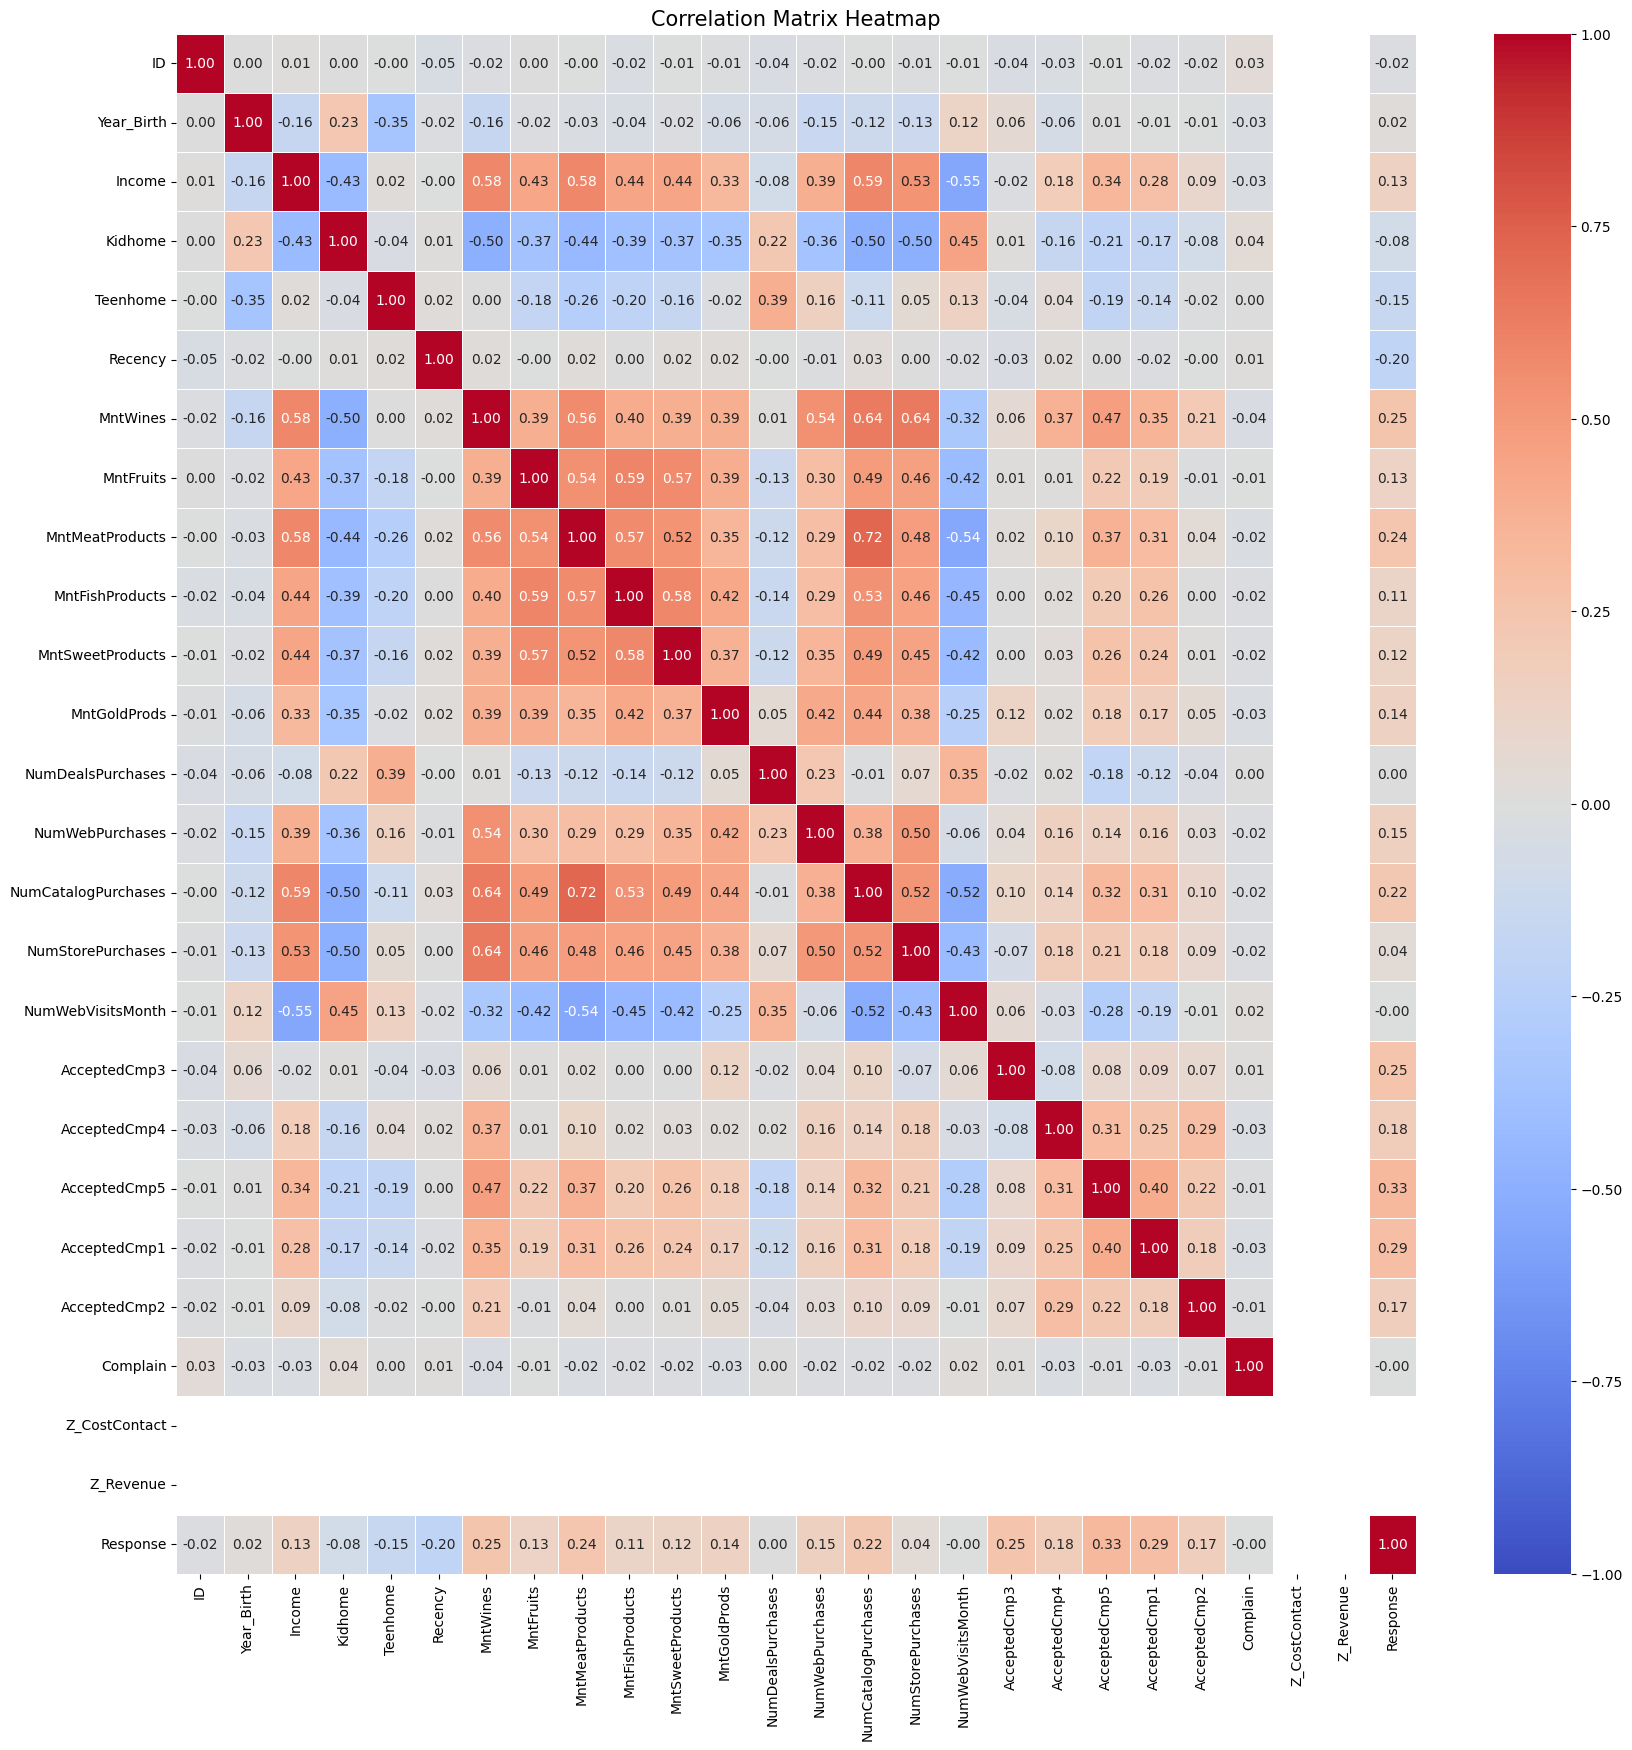

In [4]:
corr_matrix = df.corr(method='pearson', numeric_only=True)
print("--- 상관계수 행렬 ---")
print(corr_matrix)

# 3. 히트맵(Heatmap) 시각화
plt.figure(figsize=(20, 20))

# annot=True: 네모 칸 안에 숫자를 표시
# cmap='coolwarm': 양의 상관관계는 빨간색, 음의 상관관계는 파란색으로 표시
# vmin=-1, vmax=1: 색상 범위를 -1에서 1로 고정
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",       # 숫자가 겹치지 않게 소수점 둘째 자리까지만 표시
            cmap='coolwarm', # 파란색(음수) ~ 하얀색(0) ~ 빨간색(양수)
            vmin=-1,         # 최솟값은 무조건 -1
            vmax=1,          # 최댓값은 무조건 1
            linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=15)
plt.show()

## Feature Engineering
Let data collect date is 2014-08-01
1. Year_Birth to Age
2. Dt_Customer to Enrollment_days
3. Mnt* to TotalSpent
4. Accepted* to TotalCmp

In [5]:
df_eng = df.copy(deep=True)

In [6]:
df_eng['Age'] = 2014-df['Year_Birth']

(array([ 61., 240., 394., 540., 350., 336., 260.,  54.,   2.,   0.,   0.,
          0.,   0.,   1.,   2.]),
 array([ 18.        ,  24.86666667,  31.73333333,  38.6       ,
         45.46666667,  52.33333333,  59.2       ,  66.06666667,
         72.93333333,  79.8       ,  86.66666667,  93.53333333,
        100.4       , 107.26666667, 114.13333333, 121.        ]),
 <BarContainer object of 15 artists>)

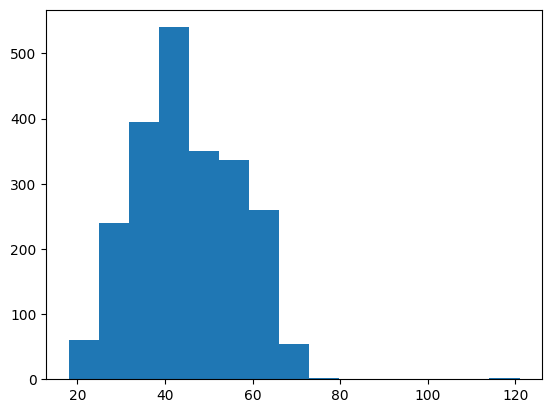

In [7]:
plt.plot()
plt.hist(df_eng['Age'], bins=15)

In [8]:
df_eng['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [9]:
df_eng['Enrollment_Days'] = (datetime.strptime('2014-08-01', '%Y-%m-%d') - df_eng['Dt_Customer']).dt.days

(array([ 74.,  97.,  88.,  97.,  87.,  85.,  77.,  78.,  96., 101.,  93.,
         93.,  87.,  88.,  91.,  84.,  93., 105.,  75.,  95.,  79.,  95.,
         81., 110.,  91.]),
 array([ 33.  ,  60.96,  88.92, 116.88, 144.84, 172.8 , 200.76, 228.72,
        256.68, 284.64, 312.6 , 340.56, 368.52, 396.48, 424.44, 452.4 ,
        480.36, 508.32, 536.28, 564.24, 592.2 , 620.16, 648.12, 676.08,
        704.04, 732.  ]),
 <BarContainer object of 25 artists>)

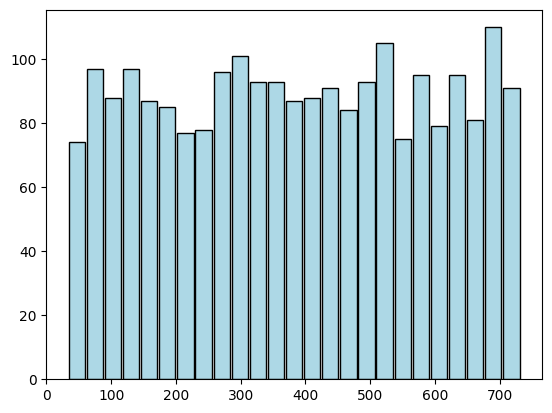

In [10]:
plt.plot()
plt.hist(df_eng['Enrollment_Days'], bins=25, color='lightblue',edgecolor='black', rwidth=0.90)

In [11]:
df_eng['Total_Spent'] = df['MntFishProducts'] + df['MntFruits'] + df['MntWines'] + df['MntSweetProducts'] + df['MntGoldProds'] + df['MntMeatProducts']

(array([731., 175., 127., 107., 115.,  75.,  68.,  79.,  84.,  91.,  86.,
         91.,  60.,  60.,  56.,  56.,  46.,  36.,  29.,  24.,  20.,   9.,
          7.,   3.,   5.]),
 array([   5. ,  105.8,  206.6,  307.4,  408.2,  509. ,  609.8,  710.6,
         811.4,  912.2, 1013. , 1113.8, 1214.6, 1315.4, 1416.2, 1517. ,
        1617.8, 1718.6, 1819.4, 1920.2, 2021. , 2121.8, 2222.6, 2323.4,
        2424.2, 2525. ]),
 <BarContainer object of 25 artists>)

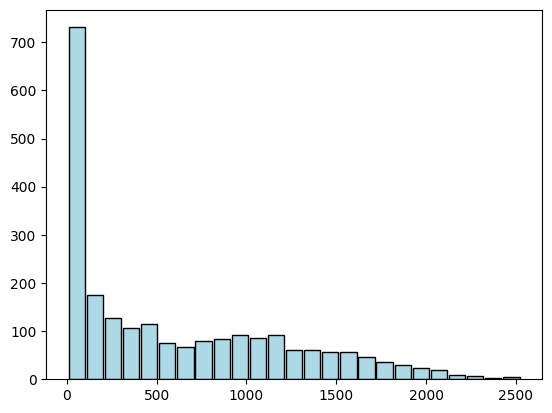

In [12]:
plt.plot()
plt.hist(df_eng['Total_Spent'], bins=25, color='lightblue',edgecolor='black', rwidth=0.90)

In [13]:
df_eng['Total_Acp'] = df['AcceptedCmp1'] +df['AcceptedCmp2'] +df['AcceptedCmp3'] +df['AcceptedCmp4'] +df['AcceptedCmp5']

(array([1777.,  325.,   83.,   55.]),
 array([0., 1., 2., 3., 4.]),
 <BarContainer object of 4 artists>)

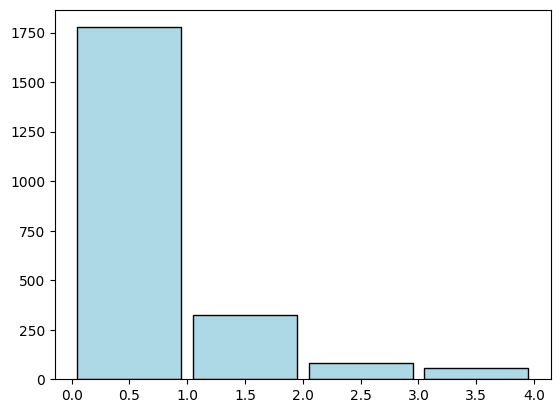

In [14]:
plt.plot()
plt.hist(df_eng['Total_Acp'], bins=4, color='lightblue',edgecolor='black', rwidth=0.90)

## Dirty Data Cleaning

1. Delete Z* columns
2. 위에서 변환한 피쳐들 제거
3. Delete Missing value (Income)

In [15]:
df_clean = df_eng.drop(['Z_CostContact','Z_Revenue'],axis=1)
df_clean = df_clean.drop(['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5'],axis=1)
df_clean = df_clean.drop(['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'],axis=1)
df_clean = df_clean.drop(['Dt_Customer','Year_Birth'],axis=1)

In [16]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Recency              2240 non-null   int64  
 7   NumDealsPurchases    2240 non-null   int64  
 8   NumWebPurchases      2240 non-null   int64  
 9   NumCatalogPurchases  2240 non-null   int64  
 10  NumStorePurchases    2240 non-null   int64  
 11  NumWebVisitsMonth    2240 non-null   int64  
 12  Complain             2240 non-null   int64  
 13  Response             2240 non-null   int64  
 14  Age                  2240 non-null   int64  
 15  Enrollment_Days      2240 non-null   int64  
 16 

In [17]:
df_clean = df_clean.dropna(axis=0)

In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Education            2216 non-null   str    
 2   Marital_Status       2216 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2216 non-null   int64  
 5   Teenhome             2216 non-null   int64  
 6   Recency              2216 non-null   int64  
 7   NumDealsPurchases    2216 non-null   int64  
 8   NumWebPurchases      2216 non-null   int64  
 9   NumCatalogPurchases  2216 non-null   int64  
 10  NumStorePurchases    2216 non-null   int64  
 11  NumWebVisitsMonth    2216 non-null   int64  
 12  Complain             2216 non-null   int64  
 13  Response             2216 non-null   int64  
 14  Age                  2216 non-null   int64  
 15  Enrollment_Days      2216 non-null   int64  
 16  Tota

## Data Inspecting

--- 상관계수 행렬 ---
                           ID    Income   Kidhome  Teenhome   Recency  \
ID                   1.000000  0.013095  0.001736 -0.003030 -0.044376   
Income               0.013095  1.000000 -0.428669  0.019133 -0.003970   
Kidhome              0.001736 -0.428669  1.000000 -0.039869  0.011492   
Teenhome            -0.003030  0.019133 -0.039869  1.000000  0.013838   
Recency             -0.044376 -0.003970  0.011492  0.013838  1.000000   
NumDealsPurchases   -0.040612 -0.083101  0.216913  0.386246  0.002115   
NumWebPurchases     -0.018476  0.387878 -0.371977  0.162077 -0.005641   
NumCatalogPurchases -0.002274  0.589162 -0.504501 -0.112692  0.024081   
NumStorePurchases   -0.013070  0.529362 -0.501349  0.049737 -0.000434   
NumWebVisitsMonth   -0.007794 -0.553088  0.447477  0.131240 -0.018564   
Complain             0.034154 -0.027225  0.040978  0.003307  0.013637   
Response            -0.021491  0.133047 -0.077909 -0.153901 -0.199766   
Age                 -0.002355  0.16

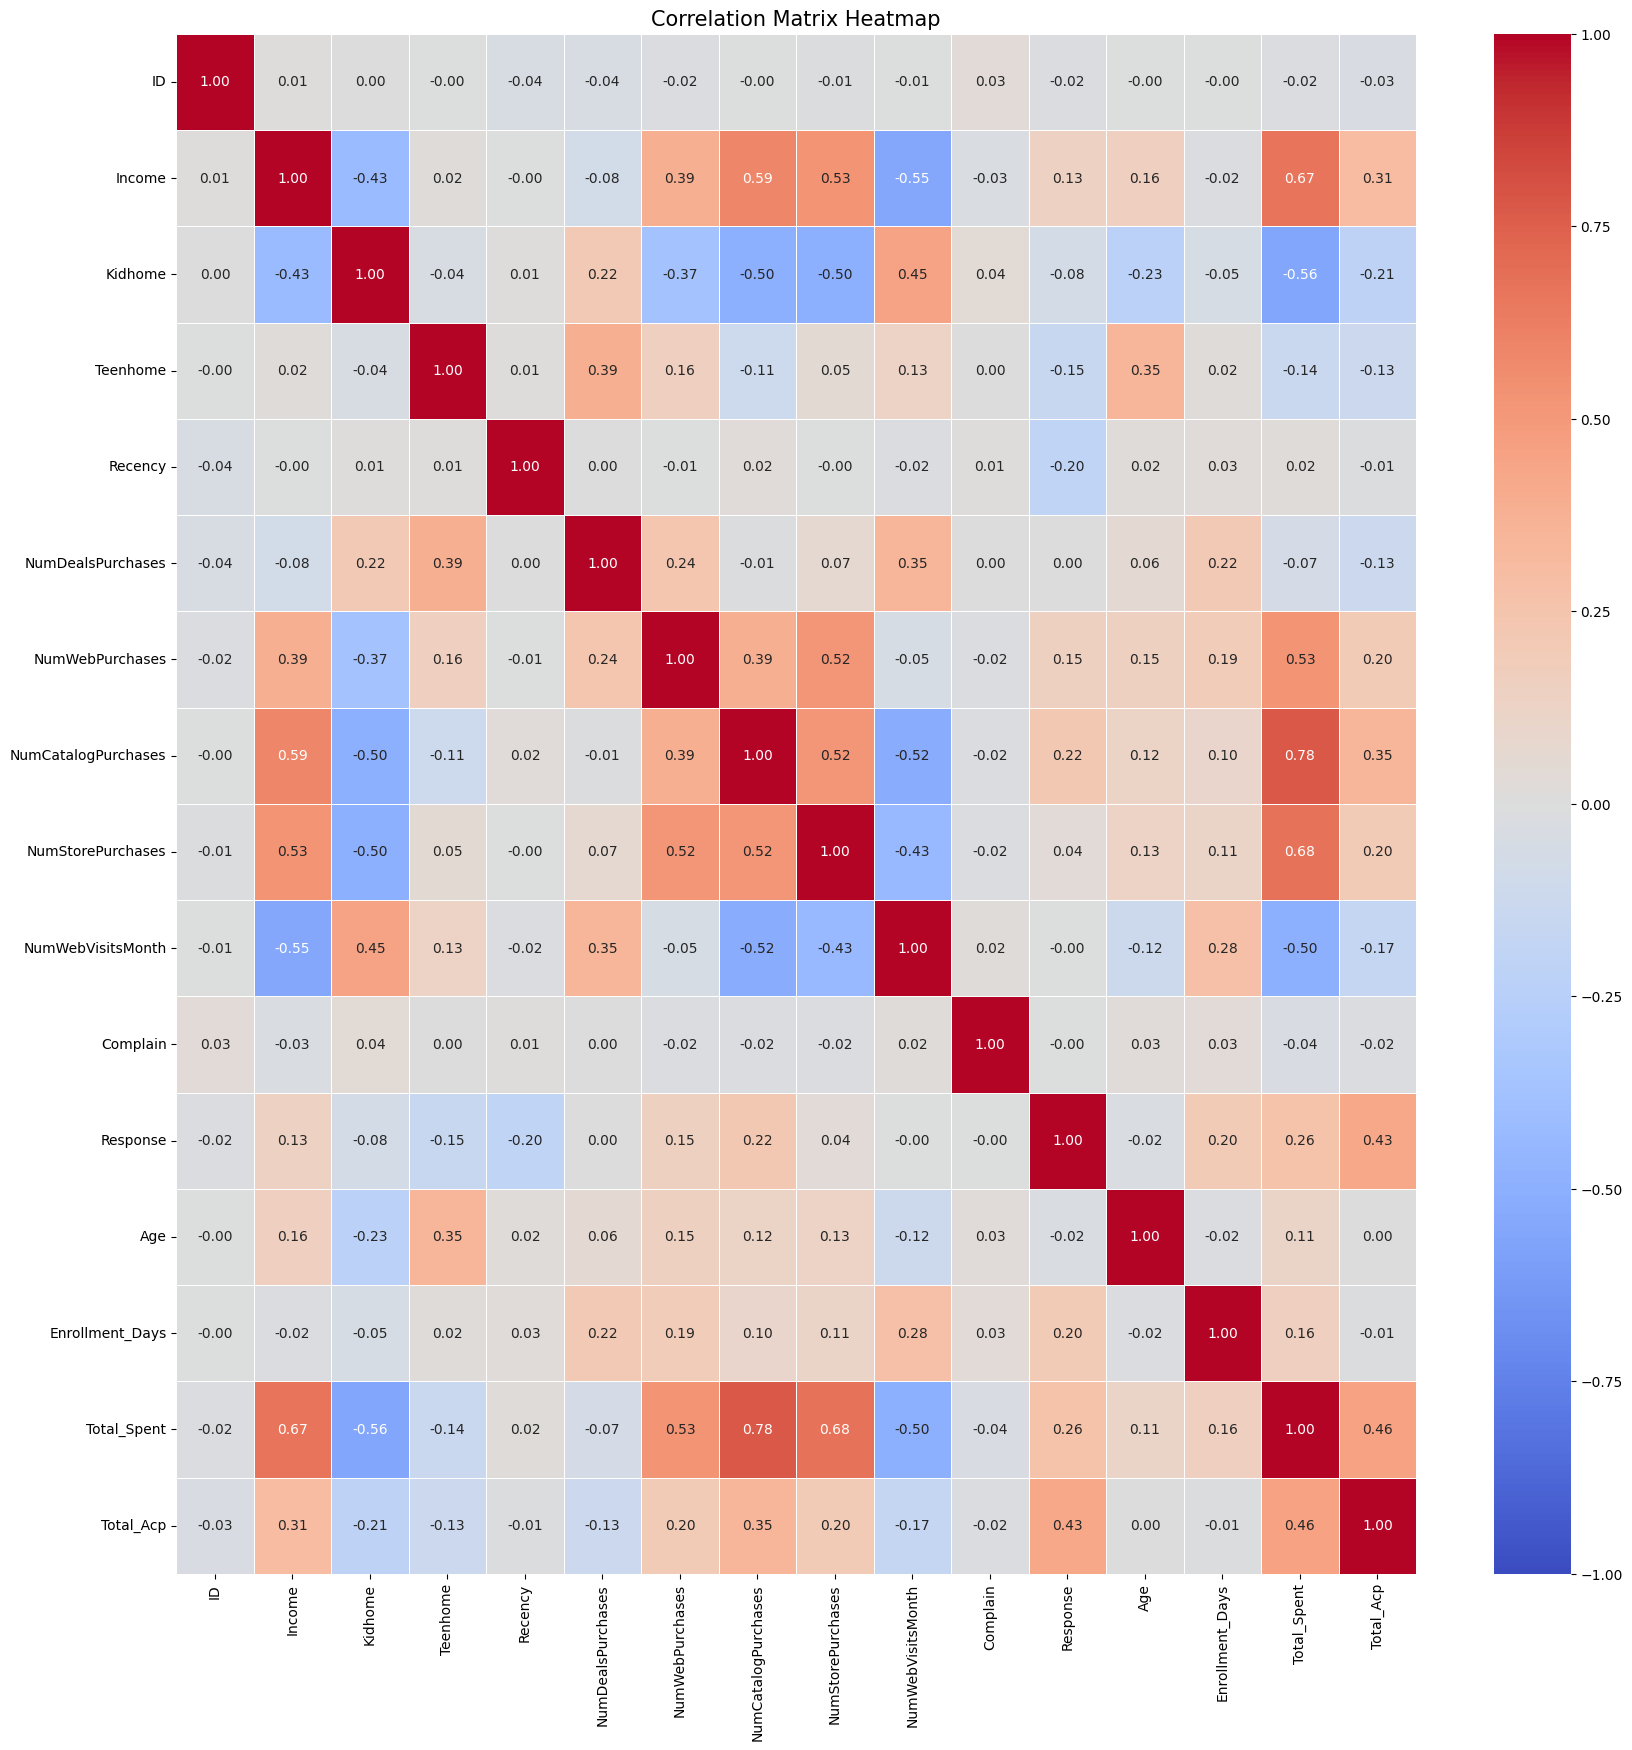

In [19]:
corr_matrix = df_clean.corr(method='pearson', numeric_only=True)
print("--- 상관계수 행렬 ---")
print(corr_matrix)

# 3. 히트맵(Heatmap) 시각화
plt.figure(figsize=(20, 20))

# annot=True: 네모 칸 안에 숫자를 표시
# cmap='coolwarm': 양의 상관관계는 빨간색, 음의 상관관계는 파란색으로 표시
# vmin=-1, vmax=1: 색상 범위를 -1에서 1로 고정
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",       # 숫자가 겹치지 않게 소수점 둘째 자리까지만 표시
            cmap='coolwarm', # 파란색(음수) ~ 하얀색(0) ~ 빨간색(양수)
            vmin=-1,         # 최솟값은 무조건 -1
            vmax=1,          # 최댓값은 무조건 1
            linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=15)
plt.show()

I think Use Total_Acp, Total_Spent, Enrollment_Days, NumCatalogPurchases, (NumWebPurchases, Income) to classification

# Data Preprocessing


In [20]:
# Use feature groups from demographic, family, relationship, spending,
# purchase channel, and campaign variables.
model_features = [
    'Age', 'Income', 'Education', 'Marital_Status',
    'Kidhome', 'Teenhome', 'Recency', 'Enrollment_Days',
    'Total_Spent', 'Total_Acp',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Complain'
]
target = 'Response'

model_df = df_clean.loc[:, model_features + [target]].copy()
model_df['Total_Spent_log'] = np.log1p(model_df['Total_Spent'])
model_df = model_df.drop(columns=['Total_Spent'])

print(model_df.shape)
print(model_df[target].value_counts(normalize=True).rename('ratio'))


(2216, 17)
Response
0    0.849729
1    0.150271
Name: ratio, dtype: float64


In [21]:
print(model_df.head())
print(model_df.info())


   Age   Income   Education Marital_Status  Kidhome  Teenhome  Recency  \
0   57  58138.0  Graduation         Single        0         0       58   
1   60  46344.0  Graduation         Single        1         1       38   
2   49  71613.0  Graduation       Together        0         0       26   
3   30  26646.0  Graduation       Together        1         0       26   
4   33  58293.0         PhD        Married        1         0       94   

   Enrollment_Days  Total_Acp  NumDealsPurchases  NumWebPurchases  \
0              696          0                  3                8   
1              146          0                  2                1   
2              345          0                  1                8   
3              172          0                  2                2   
4              194          0                  5                5   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
0                   10                  4                  7      

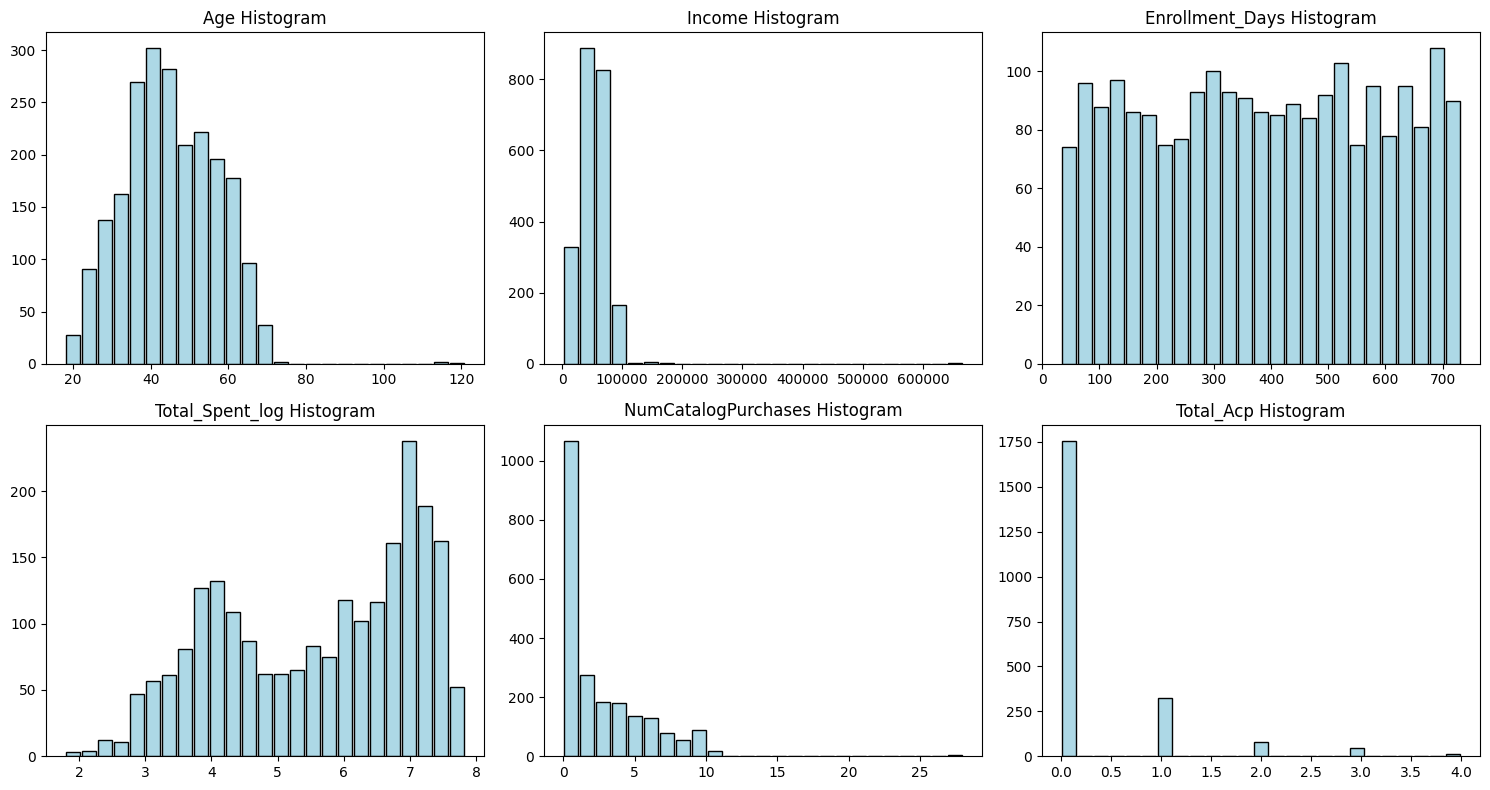

In [22]:
numeric_features_for_plot = ['Age', 'Income', 'Enrollment_Days', 'Total_Spent_log', 'NumCatalogPurchases', 'Total_Acp']
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

for idx, col_name in enumerate(numeric_features_for_plot):
    row, col = divmod(idx, 3)
    ax[row][col].hist(model_df[col_name], bins=25, color='lightblue', edgecolor='black', rwidth=0.90)
    ax[row][col].set_title(f'{col_name} Histogram', fontsize=12)

plt.tight_layout()
plt.show()


Check whether `NumCatalogPurchases > 8` behaves like an outlier before modeling.


In [23]:
catalog_outliers = model_df[model_df['NumCatalogPurchases'] > 8]
print(catalog_outliers[target].value_counts())
print(catalog_outliers.shape)


Response
0    70
1    42
Name: count, dtype: int64
(112, 17)


In [24]:
# Keep rows where NumCatalogPurchases is 8 or lower.
model_df = model_df[model_df['NumCatalogPurchases'] <= 8].copy()

X = model_df.drop(columns=[target])
y = model_df[target]

categorical_features = ['Education', 'Marital_Status']
numeric_features = [col for col in X.columns if col not in categorical_features]

print(X.shape, y.shape)
print(y.value_counts())
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)


(2104, 16) (2104,)
Response
0    1813
1     291
Name: count, dtype: int64
Numeric features: ['Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Enrollment_Days', 'Total_Acp', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Total_Spent_log']
Categorical features: ['Education', 'Marital_Status']


# 1. Classification Model

The required classification task is to predict `Response`. Candidate classification algorithms are selected from models taught in class, including Logistic Regression, K-Nearest Neighbors, and Decision Tree. A simple baseline model is used first, and then classification models are compared to check whether they improve prediction performance.

| Modeling Item | Plan |
| --- | --- |
| Target | `Response` (0/1) |
| Features | Demographic, family, customer relationship, spending, purchase channel, and campaign variables |
| Preprocessing | Missing value handling, one-hot encoding, scaling, derived features |
| Validation | Stratified k-fold cross validation |
| Evaluation metrics | Accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC |


## Train/Test Split and Preprocessing Pipeline


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## Baseline Model


In [27]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
print('Baseline accuracy:', accuracy_score(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred, zero_division=0))


Baseline accuracy: 0.8622327790973872
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       363
           1       0.00      0.00      0.00        58

    accuracy                           0.86       421
   macro avg       0.43      0.50      0.46       421
weighted avg       0.74      0.86      0.80       421



## Candidate Classification Models


In [28]:
model_configs = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
        },
    },
    'KNN': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('model', KNeighborsClassifier()),
        ]),
        'params': {
            'model__n_neighbors': range(3, 32, 2),
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan'],
        },
    },
    'Decision Tree': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
        ]),
        'params': {
            'model__max_depth': [3, 4, 5, 6, None],
            'model__min_samples_leaf': [1, 5, 10, 20],
            'model__criterion': ['gini', 'entropy'],
        },
    },
}

best_models = {}
cv_results = []

for model_name, config in model_configs.items():
    grid_search = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['params'],
        scoring='f1',
        cv=cv,
        n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)
    best_models[model_name] = grid_search.best_estimator_
    cv_results.append({
        'Model': model_name,
        'Best CV F1': grid_search.best_score_,
        'Best Params': grid_search.best_params_,
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('Best CV F1', ascending=False)
cv_results_df


,Model,Best CV F1,Best Params
0,Logistic Regression,0.540387,{'model__C': 10}
2,Decision Tree,0.472054,"{'model__criterion': 'entropy', 'model__max_de..."
1,KNN,0.463933,"{'model__metric': 'euclidean', 'model__n_neigh..."


## Test Set Evaluation


In [29]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    row = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
    }

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
        row['ROC-AUC'] = roc_auc_score(y_test, y_score)
        row['PR-AUC'] = average_precision_score(y_test, y_score)

    return row

comparison_rows = [
    evaluate_model('Baseline', baseline_model, X_test, y_test),
]

for model_name, model in best_models.items():
    comparison_rows.append(evaluate_model(model_name, model, X_test, y_test))

comparison_df = pd.DataFrame(comparison_rows).sort_values('F1', ascending=False)
comparison_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
1,Logistic Regression,0.843230,0.462963,0.862069,0.602410,0.919089,0.715510
3,Decision Tree,0.878860,0.559322,0.568966,0.564103,0.748670,0.377617
2,KNN,0.895487,0.718750,0.396552,0.511111,0.831718,0.566231
0,Baseline,0.862233,0.000000,0.000000,0.000000,0.500000,0.137767


Best model: Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.84      0.90       363
           1       0.46      0.86      0.60        58

    accuracy                           0.84       421
   macro avg       0.72      0.85      0.75       421
weighted avg       0.90      0.84      0.86       421



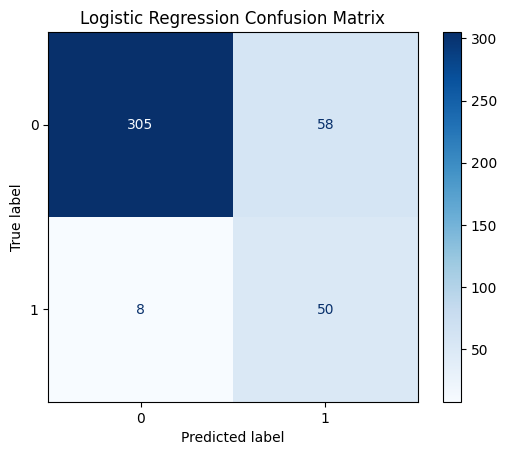

In [30]:
best_model_name = comparison_df.iloc[0]['Model']
best_model = baseline_model if best_model_name == 'Baseline' else best_models[best_model_name]

best_pred = best_model.predict(X_test)
print('Best model:', best_model_name)
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title(f'{best_model_name} Confusion Matrix')
plt.show()


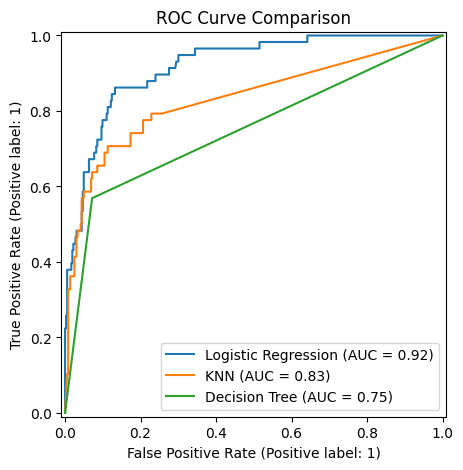

In [31]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name, model in best_models.items():
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)

plt.title('ROC Curve Comparison')
plt.show()


The final model should be selected by considering `F1` and `Recall` together because the positive class (`Response = 1`) is the important class and is much smaller than the negative class.
